# Laboratorio 12. Convolución desde cero

**Pregunta guía:** ¿Cómo detecta una convolución patrones locales y qué controla el tamaño de salida?

## Objetivos
Al finalizar podrás calcular una correlación 2D con NumPy; inspeccionar el mapa de características; verificar el resultado con `Conv2d`.

## Prerrequisitos y conexión
Aplica operaciones tensoriales de los laboratorios 00–04 a imágenes pequeñas. Se requiere Python básico; cada notebook puede ejecutarse de forma independiente desde un kernel limpio.

## Teoría breve
La salida 2D resulta de deslizar un kernel: $Y_{i,j}=\sum_{u,v}X_{i+u,j+v}K_{u,v}$. Kernel, stride y padding determinan el campo receptivo y las dimensiones.

## Problema y datos
Usamos una imagen artificial con un borde y un filtro vertical. Todos los datos se generan en el notebook: no se requieren descargas ni archivos locales.

## Experimento conceptual
¿En qué posiciones responde el filtro y coincide el cálculo manual con PyTorch? Fija la semilla, ejecuta las celdas en orden y cambia una decisión cada vez.


### Preparación del entorno
Importamos NumPy y PyTorch, fijamos semillas y elegimos CPU o GPU de forma opcional.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F

SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.figsize'] = (7, 4)
print('PyTorch:', torch.__version__, '| dispositivo:', device)


PyTorch: 2.8.0+cpu | dispositivo: cpu


**Resultado e interpretación.** La celda confirma el entorno utilizado. El resto del laboratorio está diseñado para CPU; una GPU disponible se utiliza sin ser requisito.


### Convolución manual
Recorremos la imagen y acumulamos productos locales sin usar una capa convolucional.


In [2]:
image = np.zeros((7, 7), dtype=np.float32); image[:, 3:] = 1
kernel = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
output = np.zeros((5, 5), dtype=np.float32)
for row in range(output.shape[0]):
    for column in range(output.shape[1]):
        patch = image[row:row+3, column:column+3]
        output[row, column] = np.sum(patch * kernel)
print('imagen:', image.shape, '| kernel:', kernel.shape, '| salida:', output.shape)
print(output)


imagen: (7, 7) | kernel: (3, 3) | salida: (5, 5)
[[0. 3. 3. 0. 0.]
 [0. 3. 3. 0. 0.]
 [0. 3. 3. 0. 0.]
 [0. 3. 3. 0. 0.]
 [0. 3. 3. 0. 0.]]


**Resultado e interpretación.** La respuesta alta aparece cerca del borde con orientación alineada al filtro. El kernel mostrado realiza correlación cruzada, convención habitual de `Conv2d`.


### Verificar con Conv2d y visualizar
Copiamos la imagen y el kernel a PyTorch y mostramos mapa de entrada/salida.


máxima diferencia: 0.0


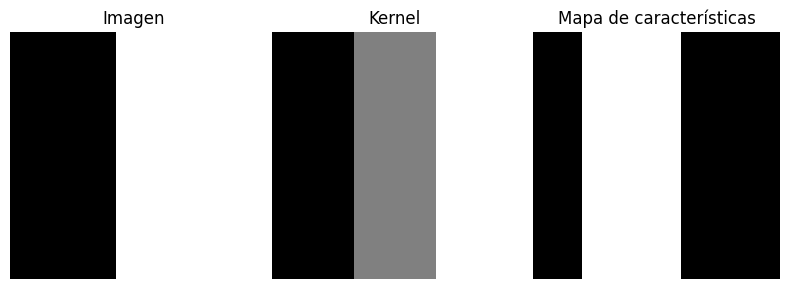

In [3]:
conv = nn.Conv2d(1, 1, kernel_size=3, bias=False)
with torch.no_grad(): conv.weight.copy_(torch.tensor(kernel)[None, None])
torch_output = conv(torch.tensor(image)[None, None]).detach().squeeze().numpy()
print('máxima diferencia:', np.abs(output - torch_output).max())
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, data, title in zip(axes, [image, kernel, output], ['Imagen', 'Kernel', 'Mapa de características']):
    ax.imshow(data, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()


**Resultado e interpretación.** La diferencia numérica debe ser cero salvo precisión. Un solo filtro muestra un patrón elegido a mano; una CNN aprende filtros con datos.


## Limitaciones y conclusiones clave
Los resultados dependen de esta semilla, tamaño de muestra, arquitectura y protocolo. No extrapoles métricas sintéticas a datos reales; separa decisiones de modelado de conclusiones generales. La celda de salida aporta la evidencia numérica y visual para responder la pregunta guía.

- Los parámetros y activaciones determinan cómo se representa la señal.
- La pérdida, el optimizador y el protocolo de evaluación forman parte del experimento.
- Una métrica aislada no describe todos los errores ni garantiza generalización.

## Ejercicios progresivos
1. **Guiado:** Guiado: cambia el kernel por uno horizontal y predice el mapa antes de ejecutarlo.
2. **Independiente:** Independiente: añade padding de un píxel y calcula la nueva forma de salida.
3. **Desafío:** Desafío: diseña un experimento que separe el efecto de stride del efecto de padding.

## Conexión con el siguiente laboratorio
Usa la representación, operación o criterio de evaluación de este laboratorio como punto de partida del siguiente paso de la secuencia.
